In [70]:
import numpy as np
import pandas as pd
#import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
#from sklearn.preprocessing import LabelEncoder , StandardScaler
from sklearn.model_selection import train_test_split

from sklearn.linear_model import Perceptron    # Used for simple linear classification tasks.

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from tensorflow.keras.models import Sequential     # Sequential lets you build a neural network layer-by-layer in Keras.

from tensorflow.keras.layers import Dense     #Dense makes the final predictions
from tensorflow.keras.layers import Conv2D     # Conv2D extracts features
from tensorflow.keras.layers import Flatten    # Flatten reshapes them

from tensorflow.keras.layers import MaxPooling2D     # MaxPooling2D reduces size
from tensorflow.keras.layers import Dropout          # Dropout prevents overfitting

from tensorflow.keras.utils import to_categorical     # converts numeric class labels into one-hot encoded format for training classification models

In [71]:
df = pd.read_csv("mnist_train.csv")
df_test = pd.read_csv("mnist_test.csv")

In [72]:
df.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [73]:
df['label'].value_counts()

,count
label,
1,4684
7,4401
3,4351
9,4188
2,4177
6,4137
0,4132
4,4072
8,4063


In [74]:
X = df.drop('label', axis=1)
y = df['label']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [75]:
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

In [76]:
X_train_img = X_train.to_numpy().reshape(-1, 28, 28)
X_test_img = X_test.to_numpy().reshape(-1, 28, 28)

In [77]:
y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

In [78]:
perceptron = Sequential([
    Flatten(input_shape=(28,28)),
    Dense(10, activation="softmax")
])

In [79]:
perceptron.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
history_percp = perceptron.fit(X_train_img, y_train_cat, epochs=5, batch_size=32,
                               validation_data=(X_test_img, y_test_cat), verbose=1)

Epoch 1/5
985/985 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8554 - loss: 0.5708 - val_accuracy: 0.9010 - val_loss: 0.3629
Epoch 2/5
985/985 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9096 - loss: 0.3305 - val_accuracy: 0.9113 - val_loss: 0.3174
Epoch 3/5
985/985 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9172 - loss: 0.2976 - val_accuracy: 0.9164 - val_loss: 0.3029
Epoch 4/5
985/985 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9207 - loss: 0.2819 - val_accuracy: 0.9179 - val_loss: 0.2931
Epoch 5/5
985/985 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9234 - loss: 0.2709 - val_accuracy: 0.9210 - val_loss: 0.2837


In [80]:
acc_percp = perceptron.evaluate(X_test_img, y_test_cat, verbose=0)[1]
acc_percp

0.9210476279258728

In [81]:
#ANN
ann = Sequential([
    Flatten(input_shape=(28,28)),
    Dense(128, activation="relu"),
    Dense(64, activation="relu"),
    Dense(10, activation="softmax")
])

ann.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
history_ann = ann.fit(X_train_img, y_train_cat, epochs=5, batch_size=32, validation_data=(X_test_img,
                      y_test_cat), verbose=1)

Epoch 1/5
985/985 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9076 - loss: 0.3116 - val_accuracy: 0.9395 - val_loss: 0.1932
Epoch 2/5
985/985 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9593 - loss: 0.1303 - val_accuracy: 0.9624 - val_loss: 0.1205
Epoch 3/5
985/985 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9736 - loss: 0.0853 - val_accuracy: 0.9692 - val_loss: 0.1008
Epoch 4/5
985/985 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9795 - loss: 0.0637 - val_accuracy: 0.9698 - val_loss: 0.0985
Epoch 5/5
985/985 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9836 - loss: 0.0508 - val_accuracy: 0.9675 - val_loss: 0.1080


In [82]:
acc_ann = ann.evaluate(X_test_img, y_test_cat, verbose=0)[1]
acc_ann

0.9675238132476807

In [83]:
X_train_cnn = X_train.to_numpy().reshape(-1, 28, 28,1)
X_test_cnn = X_test.to_numpy().reshape(-1, 28, 28, 1)

In [84]:
cnn = Sequential([
    Conv2D(32, kernel_size=(3,3), activation="relu", input_shape=(28,28,1)),
    MaxPooling2D(pool_size=(2,2)),
    Conv2D(64, kernel_size=(3,3), activation="relu"),
    MaxPooling2D(pool_size=(2,2)),
    Flatten(),
    Dense(128, activation="relu"),
    Dropout(0.5),
    Dense(10, activation="softmax")
])

cnn.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
history_cnn = cnn.fit(X_train_cnn, y_train_cat, epochs=5, batch_size=32, validation_data=(
    X_test_cnn, y_test_cat), verbose=1)

Epoch 1/5
985/985 ━━━━━━━━━━━━━━━━━━━━ 25s 24ms/step - accuracy: 0.9166 - loss: 0.2682 - val_accuracy: 0.9760 - val_loss: 0.0781
Epoch 2/5
985/985 ━━━━━━━━━━━━━━━━━━━━ 23s 23ms/step - accuracy: 0.9715 - loss: 0.0953 - val_accuracy: 0.9859 - val_loss: 0.0465
Epoch 3/5
985/985 ━━━━━━━━━━━━━━━━━━━━ 22s 22ms/step - accuracy: 0.9786 - loss: 0.0684 - val_accuracy: 0.9847 - val_loss: 0.0466
Epoch 4/5
985/985 ━━━━━━━━━━━━━━━━━━━━ 41s 22ms/step - accuracy: 0.9840 - loss: 0.0534 - val_accuracy: 0.9890 - val_loss: 0.0369
Epoch 5/5
985/985 ━━━━━━━━━━━━━━━━━━━━ 23s 23ms/step - accuracy: 0.9841 - loss: 0.0467 - val_accuracy: 0.9876 - val_loss: 0.0444


In [85]:
acc_cnn = cnn.evaluate(X_test_cnn, y_test_cat, verbose=0)[1]
acc_cnn

0.9876190423965454

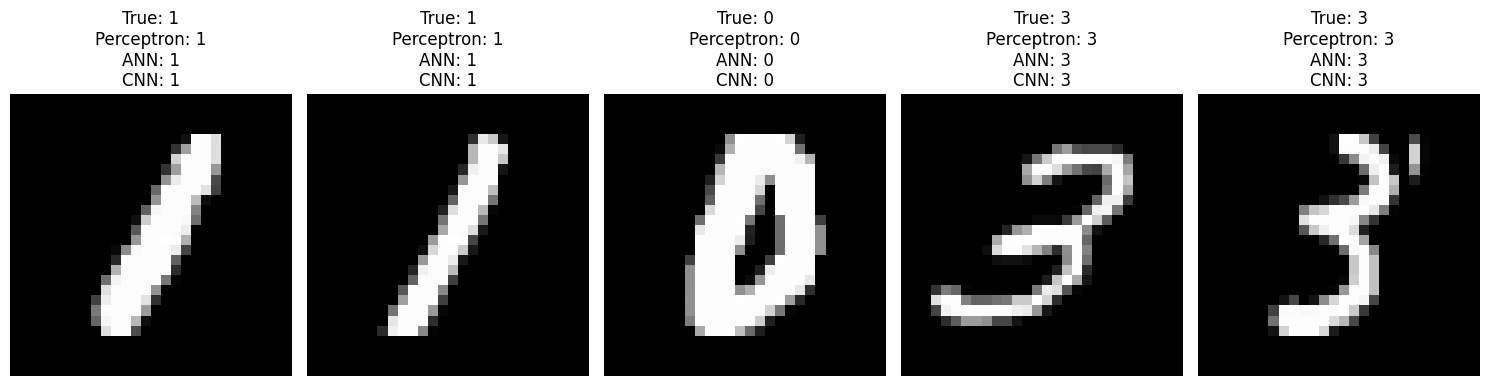

In [86]:
num_samples = 5
random_indices = np.random.choice(len(X_test_img), num_samples, replace=False)

plt.figure(figsize=(15, 8))
for i, idx in enumerate(random_indices):
    # Original Image
    img = X_test_img[idx]

    # True Label
    true_label = y_test.iloc[idx]

    # Model Predictions
    percp_pred = np.argmax(perceptron.predict(np.expand_dims(img, axis=0), verbose=0))
    ann_pred = np.argmax(ann.predict(np.expand_dims(img, axis=0), verbose=0))
    cnn_pred = np.argmax(cnn.predict(np.expand_dims(X_test_cnn[idx], axis=0), verbose=0))

    plt.subplot(1, num_samples, i + 1)
    plt.imshow(img, cmap='gray')
    plt.title(f"True: {true_label}\nPerceptron: {percp_pred}\nANN: {ann_pred}\nCNN: {cnn_pred}")
    plt.axis('off')

plt.tight_layout()
plt.show()